# Data Science in Psychology and Neuroscience

## Class info:
* Week #7
* Day: March 2, 2026
* Time: 9:30—10:45 AM
* Location: Logan Hall 125
* <a href="https://forms.microsoft.com/r/26vAcJWrwH">Click here to submit your attendance for Week 7, Question 13!</a>
  
## Instructor info:
* Dr. Jeremy Hogeveen
* jhogeveen@unm.edu
* Logan Hall 281 (Office Hours By Appointment)
  
## Syllabus:
* <a href="https://www.dropbox.com/scl/fi/6fs6fi4kvkwtxn7j7x8ua/PSY450650_DSPN_Spring2026_Syllabus.pdf?rlkey=148e5t4ah8q2n1daclt7mp0h6&dl=0">Download here</a>

## Today's topic:
1. RStudio (.R, .Rmd)
2. Tidyverse & ggplot
    * For additional reading, see <a href="https://r4ds.had.co.nz/">R for Data Science</a> and <a href="https://www.moderndive.com/">Statistical Inference via Data Science</a>
3. Play around with a sample dataset

# Section 1: R + RStudio + Rmarkdown

* `R` is a language, `RStudio` is an Integrated Development Environment (IDE)
    * `R` : `RStudio` :: `Python` : `Spyder`

<img src='img/r_vs_rstudio.png' width='600'>

* `RMarkdown` is also useful.
    * Creates `*.Rmd` version of the code, which can be used to generate `*.html` outputs that resemble Jupyter notebooks (i.e., interleaved `markdown` and `code` chunks).
 
* Let's open R and show you a quick tour...

# Section 2: Enter the `tidyverse`

## 2.1 What's a tidyverse?

* A massive set of packages that are a bit more accessible than `r-base`
    * e.g. `ggplot2`, `dplyr`, `tidyr`, etc.
* All packages share an underlying design philosophy, grammar, and data structures.
    * <a href="https://www.tidyverse.org">For more info</a>
 
## 2.2 Why use it?

* `ggplot2` is my preferred package for data visualization
    * `Matplotlib` is great in Python, but I don't find it as flexible.
* Most (if not all) of the inferential modeling I do is in `R`.
    * These modeling functions play nicely with tidy data frames.
 
## 2.3 Installing tidyverse via conda

1. Activate conda environment:
   `conda activate dspn_env`
2. Install tidyverse:
   `conda install -c conda-forge r-tidyverse`

# Section 3: Reading in and interpreting a simple dataset

* Dataset contains the body mass index (BMI) of 1786 people, together with the number of steps each of them took on a particular day.
* Stored in two files: one for chronic stroke patients, one for age-matched controls.
    * Data should be in github repository (`../data/data_viz_exercise/*.txt`)

## 3.1 step-by-step dataset interrogation
* Loading the `tidyverse` library

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


* Loading the datasets

In [12]:
# relative filepath to the data
dir_data <- '../data/data_viz_exercise'
# dir_data <- '/Users/jeremyhogeveen/Dropbox/Winter_2026/teaching/DSPN_Spring_2026/github/data/data_viz_exercise'

# filenames
file_patients <- file.path(dir_data,'data_patients.txt')
file_controls <- file.path(dir_data,'data_controls.txt')

# load the data  in
df_patients <- read_tsv(file_patients)
df_controls <- read_tsv(file_controls)

head(df_patients)
head(df_controls)

Rows: 921 Columns: 3
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): ID, steps, bmi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 865 Columns: 3
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (3): ID, steps, bmi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ID,steps,bmi
<dbl>,<dbl>,<dbl>
3,15000,17.0
4,14861,17.2
5,14861,17.2
9,14699,16.8
12,14560,20.4
14,14560,20.5


ID,steps,bmi
<dbl>,<dbl>,<dbl>
1,15000,16.9
2,15000,16.9
6,14861,16.8
7,14861,16.8
8,14699,17.3
10,14560,20.5


* Coding diagnosis as a variable

In [14]:
# one option
# df_patients$Dx <- 1 # base r approach
# df_patients <- mutate(df_patients,Dx=1) # serial tidyverse approach
df_patients <- df_patients %>% 
    mutate(Dx=1) # tidyverse piping approach
df_controls <- df_controls %>% 
    mutate(Dx=0) # tidyverse piping approach

head(df_patients)
head(df_controls)

ID,steps,bmi,Dx
<dbl>,<dbl>,<dbl>,<dbl>
3,15000,17.0,1
4,14861,17.2,1
5,14861,17.2,1
9,14699,16.8,1
12,14560,20.4,1
14,14560,20.5,1


ID,steps,bmi,Dx
<dbl>,<dbl>,<dbl>,<dbl>
1,15000,16.9,0
2,15000,16.9,0
6,14861,16.8,0
7,14861,16.8,0
8,14699,17.3,0
10,14560,20.5,0


* Merging the data frames
    * tidyverse has inner_join(), outer_join(), left_join(), and right_joint()
    * Similar to Pandas if we need to join data frames horizontally.
    * In this case, bind_rows works perfectly for joining frames vertically.

In [15]:
df_all <- bind_rows(df_patients,df_controls)
nrow(df_all)

[1] 1786

* get some descriptive statistics for the number of steps in each group.

In [17]:
# getting summary stats by group
df_all <- df_all %>%
    mutate(Dx = as.factor(Dx)) 
table_descriptives <- df_all %>%
    group_by(Dx) %>%
    summarise(
        count = n(),
        min_steps = min(steps),
        max_steps = max(steps),
        mean_steps = mean(steps),
        sd_steps = sd(steps)
    )
print(table_descriptives)

# A tibble: 2 × 6
  Dx    count min_steps max_steps mean_steps sd_steps
  <fct> <int>     <dbl>     <dbl>      <dbl>    <dbl>
1 0       865       301     15000      8014.    3255.
2 1       921         0     15000      6891.    3674.


* Test if there is a difference in steps by Dx
* Plot this contrast in a boxplot

In [20]:
# simple t.test between Dx
mod_ttest <- t.test(steps ~ Dx, df_all)
print(mod_ttest)


	Welch Two Sample t-test

data:  steps by Dx
t = 6.8441, df = 1778, p-value = 1.055e-11
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
  800.9513 1444.3903
sample estimates:
mean in group 0 mean in group 1 
       8013.908        6891.237 



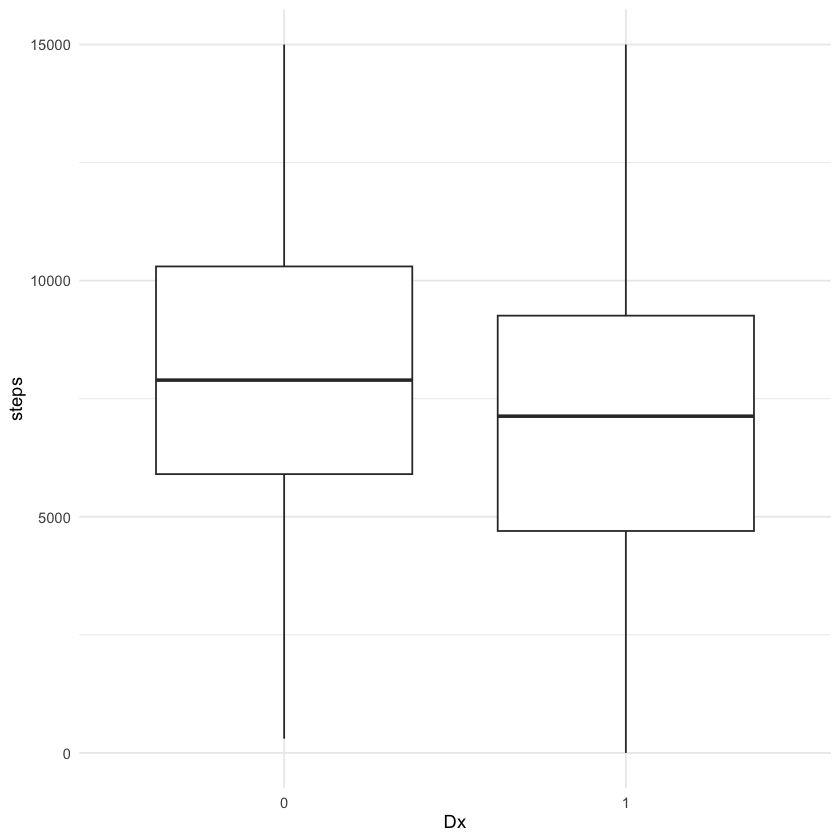

In [22]:
# plot the boxplot
plot_boxplot <- ggplot(df_all,aes(x = Dx, y = steps )) +
    geom_boxplot() +
    theme_minimal()
print(plot_boxplot)

* Testing that there is a correlation between the number of steps and the BMI for i) stroke patients, and ii) controls.
    * Run a cor test

In [23]:
# simple correlation in patients
mod_patient_correlation <- cor.test(df_patients$steps,df_patients$bmi)
print(mod_patient_correlation)


	Pearson's product-moment correlation

data:  df_patients$steps and df_patients$bmi
t = -9.968, df = 919, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.3695032 -0.2528646
sample estimates:
       cor 
-0.3123607 



In [24]:
# simple correlation in controls
mod_controls_correlation <- cor.test(df_controls$steps,df_controls$bmi)
print(mod_controls_correlation)


	Pearson's product-moment correlation

data:  df_controls$steps and df_controls$bmi
t = -6.9541, df = 863, p-value = 7.006e-12
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.2925195 -0.1662485
sample estimates:
       cor 
-0.2303534 



* Final step: lets visualize the full dataset

`geom_smooth()` using formula = 'y ~ x'


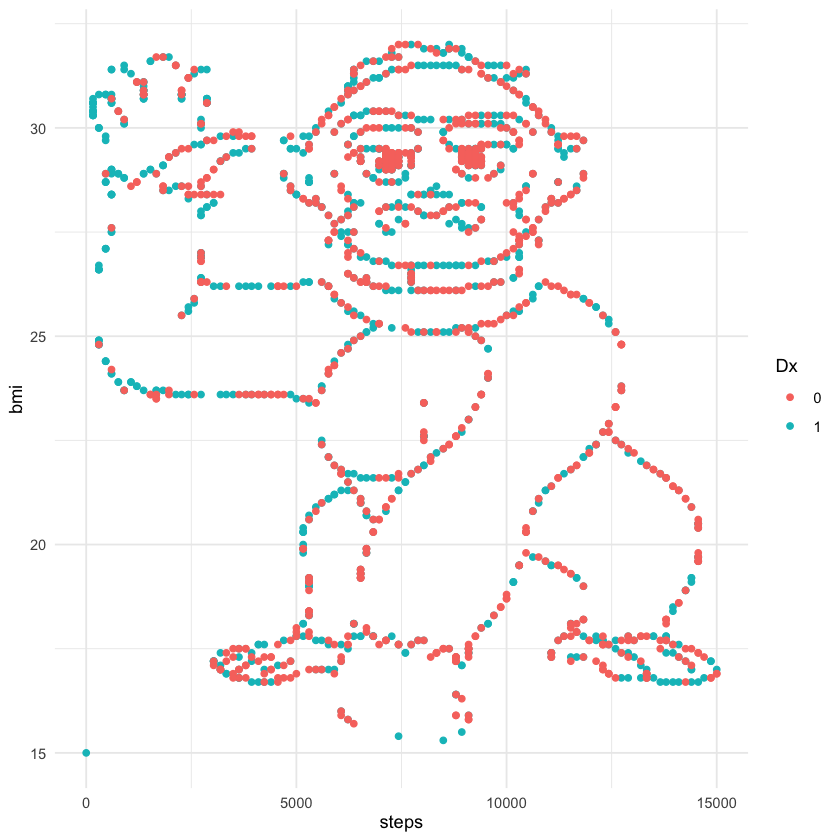

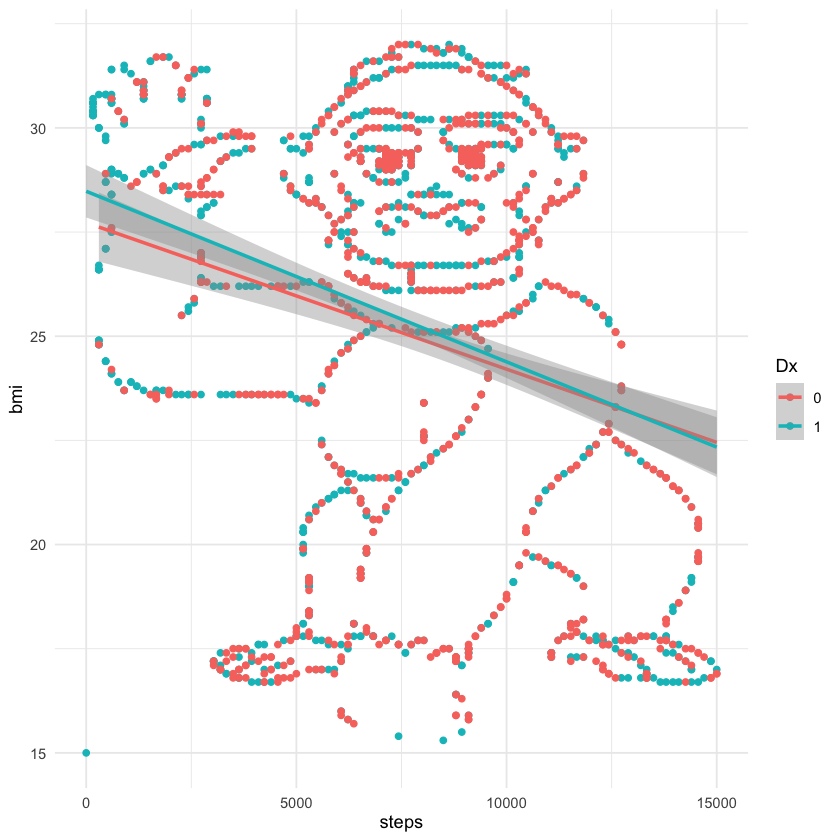

In [27]:
# plot the boxplot
plot_scatter <- ggplot(df_all,aes(x = steps, y = bmi, color = Dx )) +
    geom_point() +
    theme_minimal()
print(plot_scatter)

# plot the boxplot with line of best fit
plot_scatter_line <- ggplot(df_all,aes(x = steps, y = bmi, color = Dx )) +
    geom_point() +
    geom_smooth(method="lm") +
    theme_minimal()
print(plot_scatter_line)